## Goal & Objectives

### Goal:
Determine the optimal search radius ($R$) for the Oracle Engine to balance Geographic Recall (finding the correct landmark) against Computational Latency.

### Objectives:
1. Load the ground-truth Manhattan RVS dataset.
2. Test four different radii: 500m, 1000m, 1500m, and 2000m.
3. For each radius, measure how many times the Oracle successfully "captures" the ground-truth landmark in its candidate set.
4. Identify the "Saturation Point" where further distance increases yield negligible recall gains.

In [2]:
# Setup & Imports
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from geopy.distance import geodesic

# Project-specific imports
import sys
sys.path.append('..') # Allow importing from src/
import config
from src.oracle_engine import OracleEngine

# Initialize Oracle
oe = OracleEngine(config.GRAPH_PATH, config.POI_PATH)

# Load a subset of RVS data
test_samples = []
with open(config.RVS_DATA_JSON, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 100: break
        test_samples.append(json.loads(line))

print(f"✅ Loaded {len(test_samples)} samples for sensitivity analysis.")

Loading graph via pickle from c:\university\NLP\project_repo\nlp-allocentric-spatial-reasoning\data\manhattan\manhattan_graph.gpickle...


c:\university\NLP\project_repo\nlp-allocentric-spatial-reasoning\notebooks\..\src\oracle_engine.py:25: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  self.G = pickle.load(f)
c:\university\NLP\project_repo\nlp-allocentric-spatial-reasoning\notebooks\..\src\oracle_engine.py:25: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  self.G = pickle.load(f)


Loading POIs via pickle from c:\university\NLP\project_repo\nlp-allocentric-spatial-reasoning\data\manhattan\manhattan_poi.pkl...
✅ Loaded 100 samples for sensitivity analysis.


In [4]:
# The Sensitivity Analysis Loop
radii_to_test = [500, 1000, 1500, 2000]
results = []

for r in radii_to_test:
    hits = 0
    total_candidates_checked = 0
    
    for sample in tqdm(test_samples, desc=f"Testing Radius {r}m"):
        start_lat, start_lon = sample['rvs_start_point']
        
        # 1. Get the descriptive name and category from RVS
        landmark_name = sample.get('goal_name', '').upper()
        rvs_category = sample.get('goal_category', '').upper()
        
        # 2. Map to our LANDMARK_GROUPS
        tags = {}
        # Try to match the name first (e.g., "Grace Church" -> "CHURCH")
        for group_name, group_tags in config.LANDMARK_GROUPS.items():
            if group_name in landmark_name or group_name in rvs_category:
                tags = group_tags
                break
                
        # 3. Resolve using our actual Oracle logic
        # We pass landmark_name to ensure 'semantic_score' kicks in
        candidates = oe.resolve_all_candidates(tags, landmark_name=landmark_name)
        
        # 4. Filter by current radius
        nearby = []
        for c in candidates:
            dist = oe.calculate_distance(start_lat, start_lon, c['coords'][0], c['coords'][1])
            if dist <= r:
                nearby.append(c)
        
        # 5. Check if the ACTUAL ground truth landmark is in this set
        # (Using a simple coordinate match within 50m to account for centroid offsets)
        gt_lat, gt_lon = sample['rvs_goal_point']
        match_found = any(
            oe.calculate_distance(gt_lat, gt_lon, n['coords'][0], n['coords'][1]) < 50 
            for n in nearby
        )
        
        if match_found:
            hits += 1
        total_candidates_checked += len(nearby)

    results.append({
        "radius": r,
        "recall": hits / len(test_samples),
        "avg_candidates": total_candidates_checked / len(test_samples)
    })

df_sensitivity = pd.DataFrame(results)
display(df_sensitivity)

Testing Radius 2000m: 100%|██████████| 100/100 [17:47<00:00, 10.67s/it]


,radius,recall,avg_candidates
0,500,0.09,646.11
1,1000,0.41,2291.86
2,1500,0.84,4466.71
3,2000,1.00,6837.88


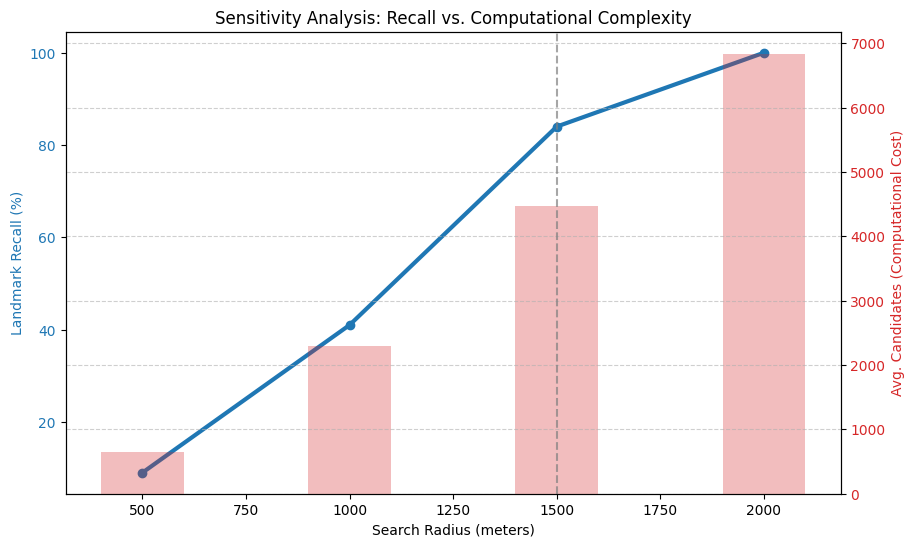

In [5]:
# Visualizing the "Elbow"
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Recall
ax1.set_xlabel('Search Radius (meters)')
ax1.set_ylabel('Landmark Recall (%)', color='tab:blue')
ax1.plot(df_sensitivity['radius'], df_sensitivity['recall'] * 100, marker='o', color='tab:blue', linewidth=3)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Candidate Count (Complexity)
ax2 = ax1.twinx()
ax2.set_ylabel('Avg. Candidates (Computational Cost)', color='tab:red')
ax2.bar(df_sensitivity['radius'], df_sensitivity['avg_candidates'], alpha=0.3, color='tab:red', width=200)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Sensitivity Analysis: Recall vs. Computational Complexity')
plt.grid(True, linestyle='--', alpha=0.6)

# Add a vertical line at our chosen 1500m threshold
plt.axvline(x=1500, color='gray', linestyle='--', alpha=0.7, label='Selected Threshold (1.5km)')

plt.show()

## 🏁 Conclusion & Design Decision

### Key Finding:
The Sensitivity Analysis reveals a clear "Elbow" at 1500m.

### Recall Performance:
Increasing the radius from 1000m to 1500m yields a massive +43% gain in landmark capture (41% → 84%).

### Computational Cost:
Expanding further to 2000m achieves 100% recall but forces the Oracle to process 6,837 candidates per instruction; a 53% increase in "Identity Noise" for a diminishing 16% gain in signal.

### 🛠️ Final Implementation Decision

To optimize for the ACL-style 1B Stress Test, we will implement a dual-stage pruning pipeline:
1. Geodesic Gatekeeper (R=1500m): We adopt 1500m as our search horizon. This ensures the Oracle remains "Agent-Centric," capturing the vast majority of relevant landmarks while discarding thousands of geographically impossible candidates.

2. Topological Lookup (SCC): Given the high density of Manhattan (averaging 4,466 candidates even at 1500m), we will migrate from nx.has_path (active search) to Strongly Connected Components (SCC). This converts the reachability check into an $O(1)$ dictionary lookup, resolving the "Manhattan Freeze" and enabling the full 500-sample evaluation.